<a href="https://colab.research.google.com/github/shreyadighe30/Hello/blob/main/Copy_of_Practical1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from collections import deque
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
# 1. Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
import os

# Path to the imperfect maze file
# Please update this path with the correct location of your maze file in Google Drive
IMPERFECT_MAZE_PATH = "/content/drive/MyDrive/EXP 1 Dataset/Maze Dataset/perfect_maze/maze200_dim49.txt"

# Base directory for Google Drive
MYDRIVE_PATH = "/content/drive/MyDrive"

# Verify if the file exists
if os.path.exists(IMPERFECT_MAZE_PATH):
    print(f"File found at: {IMPERFECT_MAZE_PATH}")
    # Load the maze as an integer array
    array = np.loadtxt(IMPERFECT_MAZE_PATH, dtype=int)

    # Print the maze
    print(array)
else:
    print(f"Error: File not found at {IMPERFECT_MAZE_PATH}")
    print("Please ensure the path is correct and the file exists in your Google Drive.")

    print(f"\nListing contents of your MyDrive ({MYDRIVE_PATH}):")
    if os.path.exists(MYDRIVE_PATH):
        for root, dirs, files in os.walk(MYDRIVE_PATH):
            level = root.replace(MYDRIVE_PATH, '').count(os.sep)
            indent = ' ' * 4 * (level)
            print(f'{indent}{os.path.basename(root)}/')
            subindent = ' ' * 4 * (level + 1)
            for f in files:
                print(f'{subindent}{f}')
    else:
        print("Error: MyDrive not mounted or accessible. Please check your Google Drive connection.")


File found at: /content/drive/MyDrive/EXP 1 Dataset/Maze Dataset/perfect_maze/maze200_dim49.txt
[[1 1 1 ... 1 1 1]
 [0 0 1 ... 0 0 1]
 [1 0 1 ... 1 0 1]
 ...
 [1 0 1 ... 1 0 1]
 [1 0 0 ... 0 0 0]
 [1 1 1 ... 1 1 1]]


In [ ]:
import matplotlib.pyplot as plt

def draw_maze(maze, path=None):
    fig, ax = plt.subplots(figsize=(10,10))

    # Set the border color to white
    fig.patch.set_edgecolor('white')
    fig.patch.set_linewidth(0)

    ax.imshow(maze, cmap=plt.cm.binary, interpolation='nearest')

    # Draw the solution path if it exists
    if path is not None:
        x_coords = [x[1] for x in path]
        y_coords = [y[0] for y in path]
        ax.plot(x_coords, y_coords, color='red', linewidth=2)

    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()


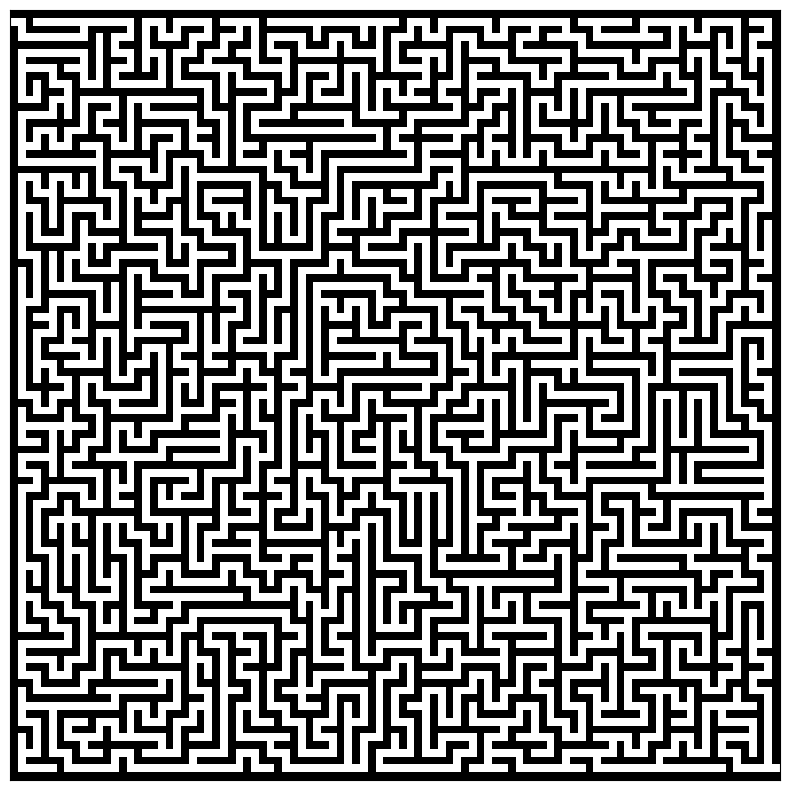

In [ ]:
draw_maze(array, path=recursive_path)

In [ ]:
def dfs_maze_solver(maze, start, goal):
    rows, cols = len(maze), len(maze[0])
    visited = [[False] * cols for _ in range(rows)]
    path = []

    def in_bounds(x, y):
        return 0 <= x < rows and 0 <= y < cols

    def dfs(x, y):
        if not in_bounds(x, y) or maze[x][y] == 1 or visited[x][y]:
            return False

        visited[x][y] = True
        path.append((x, y))

        if (x, y) == goal:
            return True
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            if dfs(x + dx, y + dy):
                return True
        path.pop()
        return False

    if dfs(*start):
        return path  # Successful path
    else:
        return None  # No path found


In [ ]:
import sys
sys.setrecursionlimit(10**6) # Increase the recursion limit for large mazes

start = (1, 1)  # We start in the upper left corner
end = (array.shape[0]-2, array.shape[1]-2)  # The exit is in the lower right corner

recursive_path = dfs_maze_solver(array, start, end)

In [ ]:
def dfs_maze_solver_iterative(maze, start, goal):
    rows, cols = len(maze), len(maze[0])
    visited = [[False for _ in range(cols)] for _ in range(rows)]
    stack = [(start, [start])]  # stack holds tuples of (current_cell, path_so_far)

    def in_bounds(x, y):
        return 0 <= x < rows and 0 <= y < cols

    while stack:
        (x, y), path = stack.pop()

        if not in_bounds(x, y) or maze[x][y] == 1 or visited[x][y]:
            continue

        visited[x][y] = True

        if (x, y) == goal:
            return path  # Found the goal

        # Explore directions: up, down, left, right
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if in_bounds(nx, ny) and not visited[nx][ny] and maze[nx][ny] == 0:
                stack.append(((nx, ny), path + [(nx, ny)]))

    return


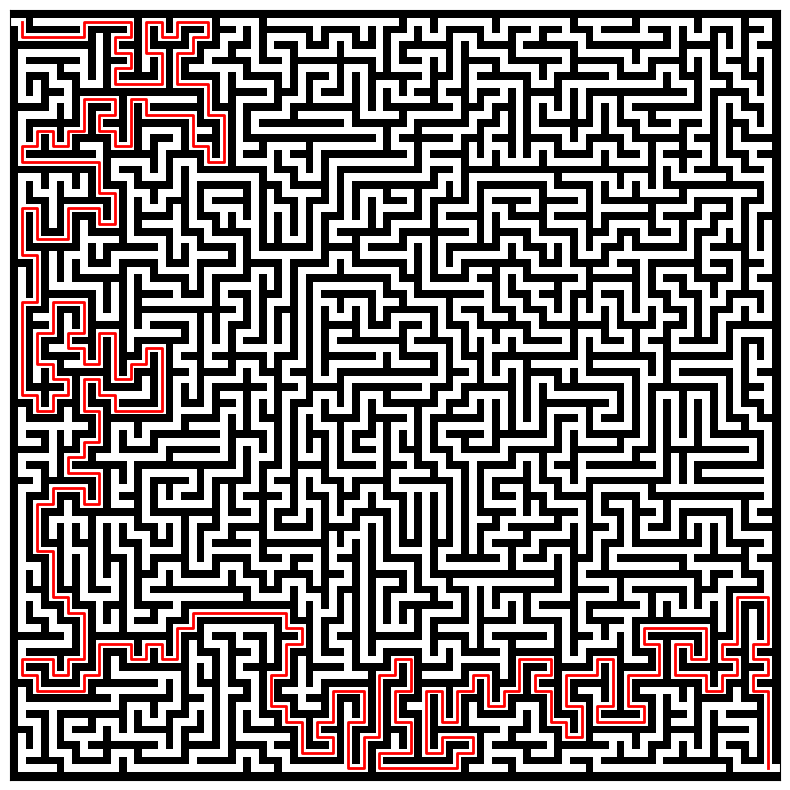

In [ ]:
iterative_path = dfs_maze_solver_iterative(array, start, end)
draw_maze(array, path=iterative_path)


In [ ]:
from collections import deque

def bfs_maze_solver(maze, start, goal):
    rows, cols = len(maze), len(maze[0])
    visited = [[False for _ in range(cols)] for _ in range(rows)]
    queue = deque([(start, [start])])  # queue holds (cell, path_so_far)

    def in_bounds(x, y):
        return 0 <= x < rows and 0 <= y < cols

    while queue:
        (x, y), path = queue.popleft()

        if not in_bounds(x, y) or maze[x][y] == 1 or visited[x][y]:
            continue

        visited[x][y] = True

        if (x, y) == goal:
            return path

        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if in_bounds(nx, ny) and not visited[nx][ny] and maze[nx][ny] == 0:
                queue.append(((nx, ny), path + [(nx, ny)]))

    return None


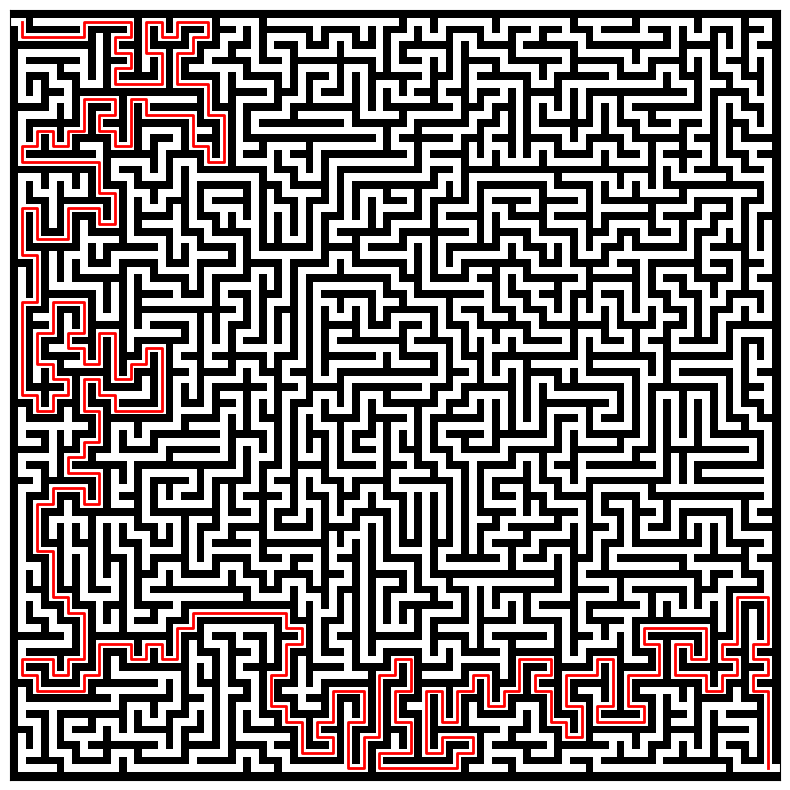

In [ ]:
shortest_path = bfs_maze_solver(array, start, end)
draw_maze(array, path=shortest_path)
